
## Spatial Understanding with Qwen3-VL

This notebook showcases Qwen3-VL's advanced spatial localization abilities, including accurate object detection, specific target grounding within images.

First of all, we list the major updates of Qwen3-VL's spatial understanding abilities as follows:
* Coordinate System: Qwen3-VL's default coordinate system has been changed from the absolute coordinates used in Qwen2.5-VL to relative coordinates ranging from 0 to 1000. (You don't need to calculate the resized_w)
* Multi-Target Grounding: Qwen3-VL has improved its multi-target grounding ability.

Now, Let's see how it integrates visual and linguistic understanding to interpret complex scenes effectively.

In [ ]:
import os
from dotenv import load_dotenv

# Load environment variables from .env file
# Required: OPENAI_API_KEY, OPENAI_BASE_URL, MODEL_ID
load_dotenv()

# Set OpenAI API credentials (required for OpenAI-compatible server)
API_KEY = os.environ["OPENAI_API_KEY"]
BASE_URL = os.environ["OPENAI_BASE_URL"]
MODEL_ID = os.environ["MODEL_ID"]

print("✓ Environment variables loaded successfully")
print(f"  API_KEY: {API_KEY[:8]}..." if API_KEY else "  API_KEY: (empty)")
print(f"  BASE_URL: {BASE_URL}")
print(f"  MODEL_ID: {MODEL_ID}")


### \[Setup\]
* step1: Prepare the environment

In [ ]:
%pip install git+https://github.com/huggingface/transformers
%pip install qwen-vl-utils
%pip install openai

* step2: Load visualization utils.

In [ ]:
import json
import random
import io
import ast
from io import BytesIO
from PIL import Image, ImageDraw, ImageFont
from PIL import ImageColor
import xml.etree.ElementTree as ET
from IPython.display import display

additional_colors = [colorname for (colorname, colorcode) in ImageColor.colormap.items()]

def decode_json_points(text: str):
    """Parse coordinate points from text format"""
    try:
        # Clean up markdown markers
        if "```json" in text:
            text = text.split("```json")[1].split("```")[0]
        
        # Parse JSON
        data = json.loads(text)
        points = []
        labels = []
        
        for item in data:
            if "point_2d" in item:
                x, y = item["point_2d"]
                points.append([x, y])
                
                # Get label, if none then use default value
                label = item.get("label", f"point_{len(points)}")
                labels.append(label)
        
        return points, labels
        
    except Exception as e:
        print(f"Error: {e}")
        return [], []
        

def plot_bounding_boxes(im, bounding_boxes):
    """
    Plots bounding boxes on an image with markers for each a name, using PIL, normalized coordinates, and different colors.

    Args:
        img_path: The path to the image file.
        bounding_boxes: A list of bounding boxes containing the name of the object
         and their positions in normalized [y1 x1 y2 x2] format.
    """

    # Load the image
    img = im
    width, height = img.size
    print(img.size)
    # Create a drawing object
    draw = ImageDraw.Draw(img)

    # Define a list of colors
    colors = [
    'red',
    'green',
    'blue',
    'yellow',
    'orange',
    'pink',
    'purple',
    'brown',
    'gray',
    'beige',
    'turquoise',
    'cyan',
    'magenta',
    'lime',
    'navy',
    'maroon',
    'teal',
    'olive',
    'coral',
    'lavender',
    'violet',
    'gold',
    'silver',
    ] + additional_colors

    # Parsing out the markdown fencing
    bounding_boxes = parse_json(bounding_boxes)

    font = ImageFont.truetype("NotoSansCJK-Regular.ttc", size=14)

    try:
      json_output = ast.literal_eval(bounding_boxes)
    except Exception as e:
      end_idx = bounding_boxes.rfind('"}') + len('"}')
      truncated_text = bounding_boxes[:end_idx] + "]"
      json_output = ast.literal_eval(truncated_text)

    if not isinstance(json_output, list):
      json_output = [json_output]

    # Iterate over the bounding boxes
    for i, bounding_box in enumerate(json_output):
      # Select a color from the list
      color = colors[i % len(colors)]

      # Convert normalized coordinates to absolute coordinates
      abs_y1 = int(bounding_box["bbox_2d"][1] / 1000 * height)
      abs_x1 = int(bounding_box["bbox_2d"][0] / 1000 * width)
      abs_y2 = int(bounding_box["bbox_2d"][3] / 1000 * height)
      abs_x2 = int(bounding_box["bbox_2d"][2] / 1000 * width)

      if abs_x1 > abs_x2:
        abs_x1, abs_x2 = abs_x2, abs_x1

      if abs_y1 > abs_y2:
        abs_y1, abs_y2 = abs_y2, abs_y1

      # Draw the bounding box
      draw.rectangle(
          ((abs_x1, abs_y1), (abs_x2, abs_y2)), outline=color, width=3
      )

      # Draw the text
      if "label" in bounding_box:
        draw.text((abs_x1 + 8, abs_y1 + 6), bounding_box["label"], fill=color, font=font)

    # Display the image
    img.show()


def plot_points(im, text):
  img = im
  width, height = img.size
  draw = ImageDraw.Draw(img)
  colors = [
    'red', 'green', 'blue', 'yellow', 'orange', 'pink', 'purple', 'brown', 'gray',
    'beige', 'turquoise', 'cyan', 'magenta', 'lime', 'navy', 'maroon', 'teal',
    'olive', 'coral', 'lavender', 'violet', 'gold', 'silver',
  ] + additional_colors

  points, descriptions = decode_json_points(text)
  print("Parsed points: ", points)
  print("Parsed descriptions: ", descriptions)
  if points is None or len(points) == 0:
    img.show()
    return

  font = ImageFont.truetype("NotoSansCJK-Regular.ttc", size=14)

  for i, point in enumerate(points):
    color = colors[i % len(colors)]
    abs_x1 = int(point[0])/1000 * width
    abs_y1 = int(point[1])/1000 * height
    radius = 2
    draw.ellipse([(abs_x1 - radius, abs_y1 - radius), (abs_x1 + radius, abs_y1 + radius)], fill=color)
    draw.text((abs_x1 - 20, abs_y1 + 6), descriptions[i], fill=color, font=font)
  
  img.show()

def plot_points_json(im, text):
  img = im
  width, height = img.size
  draw = ImageDraw.Draw(img)
  colors = [
    'red', 'green', 'blue', 'yellow', 'orange', 'pink', 'purple', 'brown', 'gray',
    'beige', 'turquoise', 'cyan', 'magenta', 'lime', 'navy', 'maroon', 'teal',
    'olive', 'coral', 'lavender', 'violet', 'gold', 'silver',
  ] + additional_colors
  font = ImageFont.truetype("NotoSansCJK-Regular.ttc", size=14)

  text = text.replace('```json', '')
  text = text.replace('```', '')
  data = json.loads(text)
  for item in data:
    point_2d = item['point_2d']
    label = item['label']
    x, y = int(point_2d[0] / 1000 * width), int(point_2d[1] / 1000 * height)
    radius = 2
    draw.ellipse([(x - radius, y - radius), (x + radius, y + radius)], fill=colors[0])
    draw.text((x + 2*radius, y + 2*radius), label, fill=colors[0], font=font)
  
  img.show()
  
  
  

# @title Parsing JSON output
def parse_json(json_output):
    # Parsing out the markdown fencing
    lines = json_output.splitlines()
    for i, line in enumerate(lines):
        if line == "```json":
            json_output = "\n".join(lines[i+1:])  # Remove everything before "```json"
            json_output = json_output.split("```")[0]  # Remove everything after the closing "```"
            break  # Exit the loop once "```json" is found
    return json_output

* step3: Prepare utils for the API calls.

In [ ]:
import requests
import os
import copy
import traceback
import time
from openai import OpenAI


def inference_with_openai_api(img_url, prompt, min_pixels=64 * 32 * 32, max_pixels=9800* 32 * 32):
    import base64
    import os
    # Strip file:// prefix from local file paths
    if img_url.startswith("file://"):
        img_url = img_url[7:]
    if os.path.exists(img_url):
        with open(img_url, "rb") as image_file:
            base64_image = base64.b64encode(image_file.read()).decode("utf-8")
    elif img_url.startswith("http://") or img_url.startswith("https://"):
        response = requests.get(img_url)
        response.raise_for_status()
        base64_image = base64.b64encode(response.content).decode("utf-8")
    else:
        raise ValueError("Invalid image URL")
    client = OpenAI(api_key=API_KEY, base_url=BASE_URL)
    messages = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/jpeg;base64,{base64_image}"
                    },
                    "min_pixels": min_pixels,
                    "max_pixels": max_pixels
                },
                {"type": "text", "text": prompt},
            ],
        }
    ]
    response = client.chat.completions.create(
        model=MODEL_ID,
        messages=messages
    )
    return response.choices[0].message.content


#### 1. Multi-Target Object Detection
Let's start with the newly-updated multi-target grounding ability.

```json
[
	{"bbox_2d": [75, 365, 319, 810], "label": "plate/dish"},
	{"bbox_2d": [282, 315, 602, 690], "label": "plate/dish"},
	{"bbox_2d": [302, 135, 477, 390], "label": "plate/dish"},
	{"bbox_2d": [322, 657, 562, 955], "label": "plate/dish"},
	{"bbox_2d": [479, 188, 741, 567], "label": "plate/dish"},
	{"bbox_2d": [550, 576, 802, 900], "label": "plate/dish"},
	{"bbox_2d": [690, 197, 988, 493], "label": "plate/dish"},
	{"bbox_2d": [747, 437, 999, 902], "label": "plate/dish"},
	{"bbox_2d": [691, 240, 770, 332], "label": "scallop"},
	{"bbox_2d": [733, 326, 830, 441], "label": "scallop"},
	{"bbox_2d": [753, 217, 847, 321], "label": "scallop"},
	{"bbox_2d": [810, 310, 911, 437], "label": "scallop"},
	{"bbox_2d": [837, 206, 913, 306], "label": "scallop"},
	{"bbox_2d": [886, 301, 976, 419], "label": "scallop"},
	{"bbox_2d": [166, 0, 302, 352], "label": "wine bottle"},
	{"bbox_2d": [0, 802, 100, 998], "label": "bowl"},
	{"bbox_2d": [255, 85, 332, 218], "label": "bowl"},
	{"bbox_2d": [612, 72,

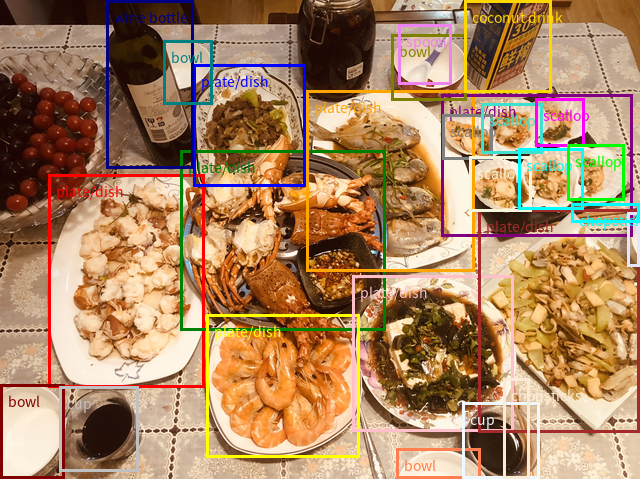

In [21]:
# Example 1: Detecting different objects on a dining table

# You can specify the categories of the instances you want to locate (negative categories are also supported and will be skipped during generation)
prompt = 'locate every instance that belongs to the following categories: "plate/dish, scallop, wine bottle, tv, bowl, spoon, air conditioner, coconut drink, cup, chopsticks, person". Report bbox coordinates in JSON format.'
img_url = "./assets/spatial_understanding/dining_table.png"
model_response = inference_with_openai_api(img_url, prompt)
print(model_response)

image = Image.open(img_url)
image.thumbnail([640,640], Image.Resampling.LANCZOS)
plot_bounding_boxes(image, model_response)
display(image)

In [ ]:
# Example 2: Detecting different objects in crowded scenes

# You can specify the categories of the instances you want to locate (negative categories are also supported and will be skipped during generation)
prompt = 'Locate every instance that belongs to the following categories: "head, hand, man, woman, glasses". Report bbox coordinates in JSON format.'
img_url = "./assets/spatial_understanding/lots_of_people.jpeg"
model_response = inference_with_openai_api(img_url, prompt)
print(model_response)

image = Image.open(img_url)
image.thumbnail([640,640], Image.Resampling.LANCZOS)
plot_bounding_boxes(image, model_response)


```json
[
	{"bbox_2d": [6, 70, 62, 154], "label": "head"},
	{"bbox_2d": [65, 5, 120, 83], "label": "head"},
	{"bbox_2d": [73, 95, 134, 175], "label": "head"},
	{"bbox_2d": [159, 10, 219, 97], "label": "head"},
	{"bbox_2d": [274, 50, 324, 125], "label": "head"},
	{"bbox_2d": [336, 0, 384, 62], "label": "head"},
	{"bbox_2d": [395, 60, 449, 137], "label": "head"},
	{"bbox_2d": [400, 0, 447, 37], "label": "head"},
	{"bbox_2d": [443, 176, 505, 263], "label": "head"},
	{"bbox_2d": [500, 96, 558, 172], "label": "head"},
	{"bbox_2d": [557, 20, 605, 89], "label": "head"},
	{"bbox_2d": [684, 238, 735, 328], "label": "head"},
	{"bbox_2d": [692, 90, 747, 180], "label": "head"},
	{"bbox_2d": [709, 0, 752, 61], "label": "head"},
	{"bbox_2d": [729, 354, 794, 463], "label": "head"},
	{"bbox_2d": [731, 84, 766, 129], "label": "head"},
	{"bbox_2d": [848, 250, 907, 337], "label": "head"},
	{"bbox_2d": [851, 701, 943, 846], "label": "head"},
	{"bbox_2d": [897, 15, 963, 93], "label": "head"},
	{"bbox_2d": 

In [ ]:
# Example 3: Detecting different objects in a 4K drone-view image

# You can specify the categories of the instances you want to locate (negative categories are also supported and will be skipped during generation)
prompt = 'Locate every instance that belongs to the following categories: "car, bus, bicycle, pedestrian". Report bbox coordinates in JSON format.'
img_url = "./assets/spatial_understanding/lots_of_cars.png"
model_response = inference_with_openai_api(img_url, prompt)
print(model_response)

image = Image.open(img_url)
image.thumbnail([640,640], Image.Resampling.LANCZOS)
plot_bounding_boxes(image, model_response)

```json
[
	{"bbox_2d": [11, 862, 54, 903], "label": "car"},
	{"bbox_2d": [0, 816, 20, 854], "label": "car"},
	{"bbox_2d": [32, 798, 71, 837], "label": "car"},
	{"bbox_2d": [42, 748, 71, 777], "label": "car"},
	{"bbox_2d": [0, 759, 23, 791], "label": "car"},
	{"bbox_2d": [171, 717, 195, 748], "label": "car"},
	{"bbox_2d": [218, 706, 262, 742], "label": "car"},
	{"bbox_2d": [229, 746, 273, 784], "label": "car"},
	{"bbox_2d": [186, 816, 226, 854], "label": "car"},
	{"bbox_2d": [177, 768, 215, 802], "label": "car"},
	{"bbox_2d": [346, 10, 365, 86], "label": "car"},
	{"bbox_2d": [349, 108, 367, 186], "label": "car"},
	{"bbox_2d": [349, 268, 370, 358], "label": "car"},
	{"bbox_2d": [382, 33, 402, 121], "label": "car"},
	{"bbox_2d": [382, 179, 402, 256], "label": "car"},
	{"bbox_2d": [385, 375, 405, 445], "label": "car"},
	{"bbox_2d": [417, 297, 436, 380], "label": "car"},
	{"bbox_2d": [448, 0, 467, 65], "label": "car"},
	{"bbox_2d": [448, 81, 467, 157], "label": "car"},
	{"bbox_2d": [449, 18

In addition, you can specify more complex requirements in grounding tasks by defining the output format, such as including additional key information like object attributes, descriptions, etc.

In [ ]:
# Example 4: Detecting vehicles with additional key information

# You can set the output format to include additional key information like object attributes, descriptions, etc.
prompt = 'locate every instance that belongs to the following categories: "vehicle". For each vehicle, report bbox coordinates, vehicle type and vehicle color in JSON format like this: {"bbox_2d": [x1, y1, x2, y2], "label": "vehicle", "type": "car, bus, truck, bicycle, ...", "color": "vehicle_color"}'
img_url = "./assets/spatial_understanding/drone_cars2.png"
model_response = inference_with_openai_api(img_url, prompt)
print(model_response)

image = Image.open(img_url)
image.thumbnail([640,640], Image.Resampling.LANCZOS)
plot_bounding_boxes(image, model_response)

```json
[
	{"bbox_2d": [318, 383, 329, 412], "label": "vehicle", "type": "bicycle", "color": "unknown"},
	{"bbox_2d": [386, 56, 398, 78], "label": "vehicle", "type": "bicycle", "color": "unknown"},
	{"bbox_2d": [352, 423, 379, 480], "label": "vehicle", "type": "car", "color": "white"},
	{"bbox_2d": [411, 354, 435, 404], "label": "vehicle", "type": "car", "color": "white"},
	{"bbox_2d": [425, 231, 445, 278], "label": "vehicle", "type": "van", "color": "white"},
	{"bbox_2d": [494, 0, 511, 25], "label": "vehicle", "type": "car", "color": "white"},
	{"bbox_2d": [371, 586, 397, 654], "label": "vehicle", "type": "car", "color": "gray"},
	{"bbox_2d": [404, 636, 431, 709], "label": "vehicle", "type": "car", "color": "light blue"},
	{"bbox_2d": [485, 607, 510, 678], "label": "vehicle", "type": "car", "color": "black"},
	{"bbox_2d": [515, 874, 545, 964], "label": "vehicle", "type": "car", "color": "white"},
	{"bbox_2d": [553, 647, 577, 720], "label": "vehicle", "type": "car", "color": "brown"},


Similarly, point-based grounding also supports the above feature.

```json
[
	{"point_2d": [40, 625], "label": "person", "role": "player", "shirt_color": "red"},
	{"point_2d": [147, 851], "label": "person", "role": "player", "shirt_color": "white"},
	{"point_2d": [150, 367], "label": "person", "role": "player", "shirt_color": "red"},
	{"point_2d": [168, 356], "label": "person", "role": "player", "shirt_color": "white"},
	{"point_2d": [177, 292], "label": "person", "role": "player", "shirt_color": "red"},
	{"point_2d": [237, 160], "label": "person", "role": "player", "shirt_color": "red"},
	{"point_2d": [243, 158], "label": "person", "role": "player", "shirt_color": "white"},
	{"point_2d": [292, 298], "label": "person", "role": "player", "shirt_color": "white"},
	{"point_2d": [333, 257], "label": "person", "role": "player", "shirt_color": "red"},
	{"point_2d": [346, 334], "label": "person", "role": "referee", "shirt_color": "black"},
	{"point_2d": [431, 148], "label": "person", "role": "player", "shirt_color": "red"},
	{"point_2d": [440, 136], "label":

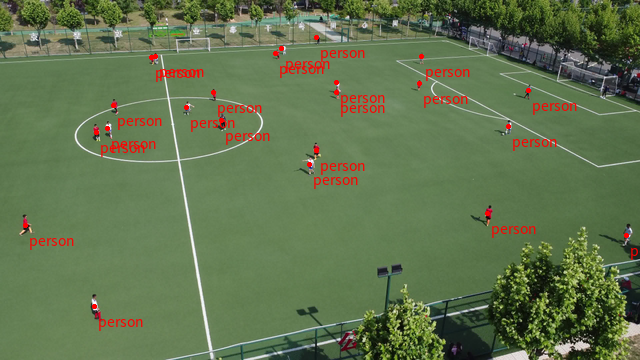

In [ ]:
# Example 5: Pointing out the people inside a football field and output their role and shirt color.

# You can also set the output format to include additional key information like object attributes, descriptions, etc in point-based grounding.
prompt = '''Locate every person inside the football field with points, report their point coordinates, role(player, referee or unknown) and shirt color in JSON format like this: {"point_2d": [x, y], "label": "person", "role": "player/referee/unknown", "shirt_color": "the person's shirt color"}'''
img_url = "./assets/spatial_understanding/football_field.jpg"
model_response = inference_with_openai_api(img_url, prompt)
print(model_response)

image = Image.open(img_url)

image.thumbnail([640,640], Image.Resampling.LANCZOS)
plot_points_json(image, model_response)
display(image)

#### 2. Detect certain object in the image

Furthermore, based on this capability, we can prompt the model with specific questions that require spatial reasoning, such as "Is object A above or below object B?" or "Please describe the object closest to object C."

In [ ]:
image_path = "./assets/spatial_understanding/spatio_case1.jpg"
prompt = "Which object, in relation to your current position, holds the farthest placement in the image?\nAnswer options:\nA.chair\nB.plant\nC.window\nD.tv stand."
model_response = inference_with_openai_api(image_path, prompt)


print(model_response)


image = Image.open(image_path)
print(image.size)
image.thumbnail([640,640], Image.Resampling.LANCZOS)
#plot_bounding_boxes(image, model_response)
display(image)

Further, you can search for a specific object by using a short phrase or sentence to describe it.

In [ ]:
image_path = "./assets/spatial_understanding/cakes.png"

prompt = "Locate the green paste in the spoon, output its bbox coordinates using JSON format."
#prompt = "Locate the top right brown cake, output its bbox coordinates using JSON format."
#prompt = "Outline the position of each small cake and output all the coordinates in JSON format."


## Use openai-style api to inference.
model_response = inference_with_openai_api(image_path, prompt)
print(model_response)

image = Image.open(image_path)
image.thumbnail([640,640], Image.Resampling.LANCZOS)
plot_bounding_boxes(image, model_response)

For spatial pointing tasks, Qwen3-VL now support these formats:

In addition to the above mentioned bbox format [x1, y1, x2, y2], Qwen2.5-VL also supports point-based grounding. You can point to a specific object and the model is trained to output xml-style results.

In [ ]:
image_path = "./assets/spatial_understanding/cakes.png"

# prompt in english
prompt = "point to the rolling pin on the far side of the table, output its coordinates in XML format <points x y>object</points>"

## Use openai-style api to inference.
model_response = inference_with_openai_api(image_path, prompt)
print(model_response)

image = Image.open(image_path)
image.thumbnail([640,640], Image.Resampling.LANCZOS)
plot_points(image, model_response)


In [ ]:
#image_path = "./assets/spatial_understanding/spatio_case2_aff.png"
image_path = "./assets/spatial_understanding/Origamis.jpg"
#prompt = "Locate the free space on the white table on the right in this image. Output the point coordinates in JSON format."
prompt = "Locate the shadow of the paper fox, report the bbox coordinates in JSON format."

model_response = inference_with_openai_api(image_path, prompt)
print(model_response)

image = Image.open(image_path)
image.thumbnail([640,640], Image.Resampling.LANCZOS)
#plot_points(image, model_response)
plot_bounding_boxes(image, model_response)

In [ ]:
#image_path = "./assets/spatial_understanding/spatio_case2_aff2.png"
image_path = "./assets/spatial_understanding/cartoon_brave_person.jpeg"
#prompt = "Can the speaker fit behind the guitar?"
prompt = "Locate the person who act bravely, report the bbox coordinates in JSON format."

## Use openai-style api to inference.
model_response = inference_with_openai_api(image_path, prompt)
print(model_response)

image = Image.open(image_path)
image.thumbnail([640,640], Image.Resampling.LANCZOS)
plot_bounding_boxes(image, model_response)

import io
#### 3. Integrate Spatial Reasoning and Action Planning

This advanced task integrates the understanding of spatial relationships and affordances. The model must synthesize these capabilities to select the correct action that achieves a goal, effectively reasoning like an embodied agent.

In [ ]:
#image_path = "./assets/spatial_understanding/spatio_case2_plan.png"
image_path = "./assets/spatial_understanding/multiple_items.png"
#prompt = "What color arrow should the robot follow to move the apple in between the green can and the orange? Choices: A. Red. B. Blue. C. Green. D. Orange."
#prompt = "If the sun is very glaring, which item in this image should I use? Please locate it in the image with its bbox coordinates and its label and output in JSON format."
prompt = "In the beach, which items in this image should I use? Please locate they in the image with its bbox coordinates and its labels and output in JSON format., and explain why"

model_response = inference_with_openai_api(image_path, prompt)
print(model_response)

image = Image.open(image_path)
image.thumbnail([640,640], Image.Resampling.LANCZOS)
plot_bounding_boxes(image, model_response)

import io
#### 7. Known Limitations
* When the number of instances in a particular category significantly exceeds 40-50 or when objects are densely packed, the model may enter an endless generation loop.
* The model occasionally detects a cluster of closely spaced objects as a single bounding box. This issue can be mitigated by refining the input prompt.

import io
#### 8. spatial understanding with designed system prompt
The above usage is based on the default system prompt. You can also change the system prompt to obtain other output format like plain text.
Qwen3-VL now support these formats:
* bbox-format: JSON (default)

from IPython.display import Markdown, display
import numpy as np
from PIL import Image
import decord
from decord import VideoReader, cpu


def download_video(url, dest_path):
    response = requests.get(url, stream=True)
    with open(dest_path, 'wb') as f:
        for chunk in response.iter_content(chunk_size=8096):
            f.write(chunk)
    print(f"Video downloaded to {dest_path}")


def get_video_frames(video_path, num_frames=128, cache_dir='./assets/spatial_understanding/'):
    os.makedirs(cache_dir, exist_ok=True)

* point-format: JSON (default)

    frames_cache_file = os.path.join(cache_dir, f'{video_hash}_{num_frames}_frames.npy')
    timestamps_cache_file = os.path.join(cache_dir, f'{video_hash}_{num_frames}_timestamps.npy')

    if os.path.exists(frames_cache_file) and os.path.exists(timestamps_cache_file):
        frames = np.load(frames_cache_file)
        timestamps = np.load(timestamps_cache_file)
        return video_file_path, frames, timestamps

    vr = VideoReader(video_file_path, ctx=cpu(0))
    total_frames = len(vr)

    indices = np.linspace(0, total_frames - 1, num=num_frames, dtype=int)
    frames = vr.get_batch(indices).asnumpy()
    timestamps = np.array([vr.get_frame_timestamp(idx) for idx in indices])

    np.save(frames_cache_file, frames)
    np.save(timestamps_cache_file, timestamps)
    
    return video_file_path, frames, timestamps


def create_image_grid(images, num_columns=8):
    pil_images = [Image.fromarray(image) for image in images]
    num_rows = math.ceil(len(images) / num_columns)

    img_width, img_height = pil_images[0].size
    grid_width = num_columns * img_width
    grid_height = num_rows * img_height
    grid_image = Image.new('RGB', (grid_width, grid_height))

    for idx, image in enumerate(pil_images):
        row_idx = idx // num_columns
        col_idx = idx % num_columns
        position = (col_idx * img_width, row_idx * img_height)
        grid_image.paste(image, position)

    return grid_image
